<a href="https://colab.research.google.com/github/JayAndJef/colabnotebooks/blob/main/VAE-ffhq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Variational Autoencoder (VAE) for Face Generation on FFHQ

This notebook implements a Variational Autoencoder (VAE) to learn and reconstruct human faces using the Flickr-Faces-HQ (FFHQ) dataset.

In [16]:
import kagglehub
arnaud58_flickrfaceshq_dataset_ffhq_path = kagglehub.dataset_download('arnaud58/flickrfaceshq-dataset-ffhq')

print('Data source import complete.')

Using Colab cache for faster access to the 'flickrfaceshq-dataset-ffhq' dataset.
Data source import complete.


In [17]:
import torch
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
from PIL import Image
import os
import glob

torch.set_float32_matmul_precision('high')

class FFHQDataset(Dataset):
  def __init__(self, root_dir, transform=None):
    self.root_dir = root_dir
    self.transform = transform
    self.image_paths = []
    # Search for images in the root directory only
    for ext in ('*.png', '*.jpg', '*.jpeg'):
      self.image_paths.extend(glob.glob(os.path.join(root_dir, ext)))

    self.image_paths.sort()
    print(f'Found {len(self.image_paths)} total images in {root_dir}')

  def __len__(self):
    return len(self.image_paths)

  def __getitem__(self, idx):
    img_path = self.image_paths[idx]
    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image)
    else:
      default_transform = v2.Compose([
        v2.Resize((256, 256)),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
      ])
      image = default_transform(image)

    return image

full_dataset = FFHQDataset(root_dir=arnaud58_flickrfaceshq_dataset_ffhq_path, transform=None)

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f'Training set size: {len(train_dataset)}')
print(f'Testing set size: {len(test_dataset)}')

if len(train_dataset) > 0:
  images = next(iter(train_loader))
  print(f'Batch shape: {images.shape}')

Found 52001 total images in /kaggle/input/flickrfaceshq-dataset-ffhq
Training set size: 41600
Testing set size: 10401
Batch shape: torch.Size([32, 3, 256, 256])


In [18]:
import torch
from torch import nn

class SelfAttention(nn.Module):
  def __init__(self, in_channels, num_heads=4):
    super().__init__()
    self.mha = nn.MultiheadAttention(embed_dim=in_channels, num_heads=num_heads, batch_first=True)
    self.ln = nn.LayerNorm(in_channels)

  def forward(self, x):
    B, C, H, W = x.shape
    residual = x
    # Reshape (B, C, H, W) to (B, H*W, C)
    x_flat = x.permute(0, 2, 3, 1).contiguous().view(B, H * W, C)
    x_normed = self.ln(x_flat)
    attn, _ = self.mha(x_normed, x_normed, x_normed)
    out = attn.view(B, H, W, C).permute(0, 3, 1, 2).contiguous()
    return out + residual

class Encoder(nn.Module):
  def __init__(self, latent_channels=4, in_channels=3):
    super().__init__()
    self.conv = nn.Sequential(
      nn.Conv2d(in_channels, 64, 4, stride=2, padding=1), # 3x256x256 -> 64x128x128
      nn.ReLU(inplace=True),
      nn.Conv2d(64, 128, 4, stride=2, padding=1), # 64x128x128 -> 128x64x64
      nn.ReLU(inplace=True),
      nn.Conv2d(128, 256, 4, stride=2, padding=1), # 128x64x64 -> 256x32x32
      nn.ReLU(inplace=True),
    )
    # Self attention just before the latent bottleneck
    self.attn = SelfAttention(in_channels=256, num_heads=4)

    self.conv_mu = nn.Conv2d(256, latent_channels, 1)
    self.conv_logvar = nn.Conv2d(256, latent_channels, 1)

  def forward(self, x):
    conv_output = self.conv(x)
    attn_output = self.attn(conv_output)
    mu = self.conv_mu(attn_output)
    logvar = self.conv_logvar(attn_output)
    return mu, logvar

class Decoder(nn.Module):
  def __init__(self, latent_channels=4, out_channels=3):
    super().__init__()
    self.initial_conv = nn.Sequential(
      nn.Conv2d(latent_channels, 256, 3, padding=1),
      nn.ReLU(inplace=True)
    )
    self.attn = SelfAttention(in_channels=256, num_heads=4)

    self.deconv = nn.Sequential(
      # 256x32x32 -> 128x64x64
      nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
      nn.ReLU(inplace=True),

      # 128x64x64 -> 64x128x128
      nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
      nn.ReLU(inplace=True),

      # 64x128x128 -> 3x256x256
      nn.ConvTranspose2d(64, out_channels, 4, stride=2, padding=1),
      nn.Tanh(),
    )

  def forward(self, z):
    x = self.initial_conv(z)
    x = self.attn(x)
    return self.deconv(x)

class VAE(nn.Module):
  def __init__(self, image_channels=3, latent_channels=4):
    super().__init__()
    self.encoder = Encoder(latent_channels, image_channels)
    self.decoder = Decoder(latent_channels, image_channels)

  def reparam(self, mu, logvar):
    """
    reparameterization trick to keep gradients
    """
    std = torch.exp(logvar * 0.5)
    elipson = torch.randn_like(std)
    return mu + elipson * std

  def forward(self, x):
    mu, logvar = self.encoder(x)
    z = self.reparam(mu, logvar)
    return self.decoder(z), mu, logvar


In [19]:
import torch.nn.functional as F

def vae_loss(x_out, x, mu, logvar, beta=1e-4):
  mse_term = F.mse_loss(x_out, x)
  kl_sample = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=(1, 2, 3))
  kl_loss = kl_sample.mean()
  kl_term = kl_loss * beta
  return mse_term + kl_term, mse_term, kl_term

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Epoch [1/10]: 100%|██████████| 1300/1300 [12:55<00:00,  1.68it/s, kl=0.0357, loss=0.0992, mse=0.0635]


Checkpoint saved to Google Drive for epoch 1


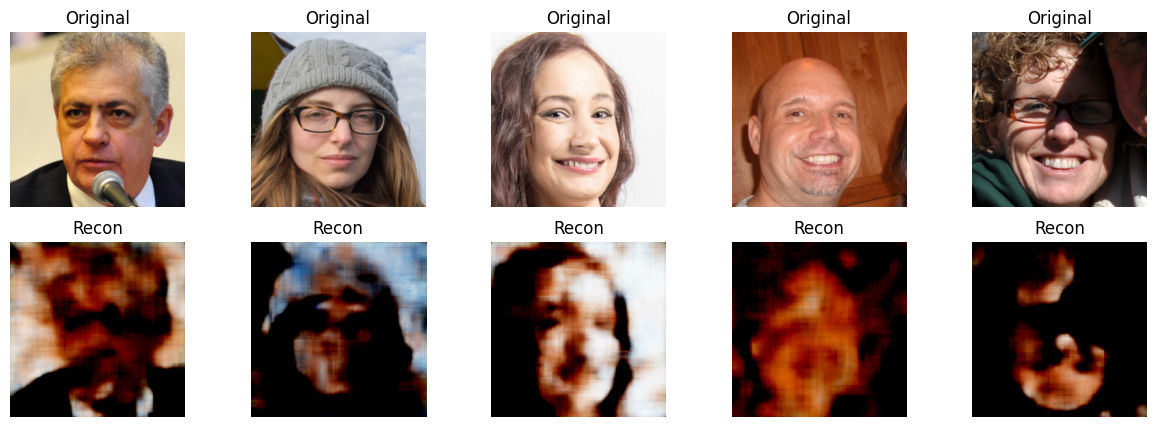

Epoch [2/10]:   1%|▏         | 19/1300 [00:11<12:55,  1.65it/s, kl=0.0313, loss=0.0875, mse=0.0563]


KeyboardInterrupt: 

In [20]:
from google.colab import drive
drive.mount('/content/drive')

from torch.optim import Adam
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
vae = VAE(latent_channels=8).to(device)
vae = torch.compile(vae)
optimizer = Adam(vae.parameters(), lr=1e-3)

NUM_EPOCHS = 10

def visualize_reconstruction(model, dataloader, device):
  model.eval()
  with torch.no_grad():
    batch = next(iter(dataloader))
    x = batch.to(device)
    x_out, _, _ = model(x)

    plt.figure(figsize=(15, 5))
    for i in range(5):
      plt.subplot(2, 5, i + 1)
      img_original = ((x[i].cpu().permute(1, 2, 0) * 0.5) + 0.5) * 255
      plt.imshow(img_original.clamp(0, 255).to(torch.uint8).numpy())
      plt.title("Original")
      plt.axis('off')

      plt.subplot(2, 5, i + 6)
      img_recon = x_out[i].cpu().permute(1, 2, 0) * 255
      plt.imshow(img_recon.clamp(0, 255).to(torch.uint8).numpy())
      plt.title("Recon")
      plt.axis('off')
    plt.show()
  model.train()

for epoch in range(NUM_EPOCHS):
  vae.train()
  loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
  for batch in loop:
    x = batch.to(device)
    x_out, mu, logvar = vae(x)
    loss, mse, kl = vae_loss(x_out, x, mu, logvar)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loop.set_postfix(loss=loss.item(), mse=mse.item(), kl=kl.item())

  torch.save(vae.state_dict(), '/content/drive/MyDrive/vae_checkpoint.pth')
  print(f"Checkpoint saved to Google Drive for epoch {epoch+1}")
  visualize_reconstruction(vae, test_loader, device)
